## Student Performance Indicator

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Import dataset

In [31]:
df =pd.read_csv('data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [32]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Check the duplicate items

In [42]:
df.duplicated().sum()

0

No missing value in the dataset

In [33]:
print(df['gender'].value_counts())
print(df["race/ethnicity"].value_counts())
print(df["parental level of education"].value_counts())
print(df["lunch"].value_counts())
print(df["test preparation course"].value_counts())

gender
female    518
male      482
Name: count, dtype: int64
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
test preparation course
none         642
completed    358
Name: count, dtype: int64


Checking how many different catogaries are there and we found that "Some high school" and "high school" represent the same catagorie, so we need to merge them

In [41]:
print(df["math score"].unique())
print(df["reading score"].unique())
print(df["writing score"].unique())


[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
[ 74  88  93  44  75  78  92  39  67  50  52  43  73  70  58  86  28  46
  61  63  53  80  72  55  65  38  82  79  83  59  57  54  68  66  62  76
  48  42  87  49  10  34  71  37  56  41  22  81  45  36  89  47  90 100
  64  98  51  40  84  69  33  60  85  91  77  27  94  95  19  35  32  96
  97  99  15  30  23]


In [35]:
df_copy = df

In [36]:
df_copy.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [37]:
df_copy["parental level of education"] = df_copy["parental level of education"].replace("some high school", "high school")

replaced all the "some high school" with "high school"

In [38]:
print(df_copy["parental level of education"].value_counts())


parental level of education
high school           375
some college          226
associate's degree    222
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


In [40]:
df_copy.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Checking the stats for numerical feature

In [43]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


define numerical and Categorical features

In [48]:
cat_feature = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'object']
num_feature = [feature for feature in df_copy.columns if feature not in cat_feature]
print("cat_feature: ",cat_feature)
print("num_feature: ",num_feature)

cat_feature:  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
num_feature:  ['math score', 'reading score', 'writing score']


## Setting an average value for the scores

In [49]:
df_copy["Total_score"] = (df_copy["math score"] + df_copy["reading score"] + df_copy["writing score"])/3

In [50]:
df_copy.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [57]:
df_copy=df_copy.drop(["math score", "reading score", "writing score"], axis=1)

# Histogram and KDE

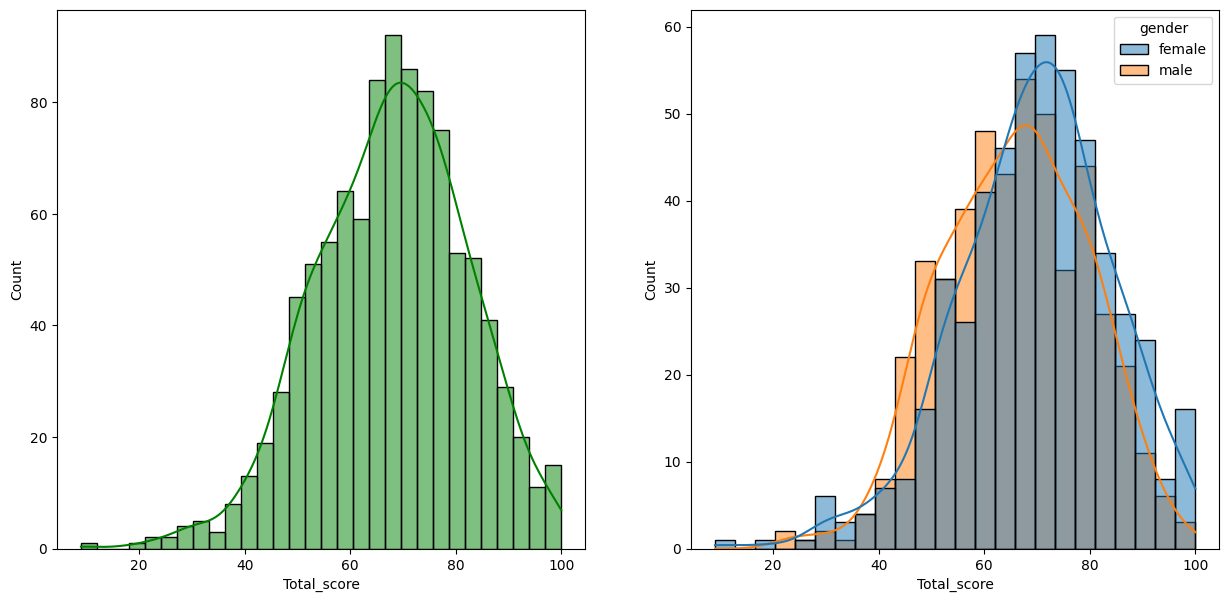

In [58]:
fig, axis = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df_copy, x="Total_score", bins=30, kde=True, color="g")
plt.subplot(122)
sns.histplot(data=df_copy, x="Total_score", kde=True, hue="gender")
plt.show()

In [59]:
df_copy.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,Total_score
0,female,group B,bachelor's degree,standard,none,72.666667
1,female,group C,some college,standard,completed,82.333333
2,female,group B,master's degree,standard,none,92.666667
3,male,group A,associate's degree,free/reduced,none,49.333333
4,male,group C,some college,standard,none,76.333333


In [61]:
df_copy.to_csv("data/modified_data.csv")